# Perceptron from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

The **Perceptron** is the simplest neural network. It is a single-layer linear classifier introduced by Rosenblatt in 1958. It makes binary predictions using:

$$\hat{y} = \begin{cases} 1 & \text{if } w \cdot x + b \geq 0 \\ 0 & \text{otherwise} \end{cases}$$

Training uses the **Perceptron learning rule**: for each misclassified point, update the weights:

$$w \leftarrow w + \eta(y - \hat{y})x$$

The Perceptron is guaranteed to converge **if and only if the data is linearly separable**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.supervised_learning.perceptron import Perceptron
from rice_ml.processing.metrics import accuracy_score, confusion_matrix
from rice_ml.processing.preprocessing import StandardScaler

## Loading and Exploring the Dataset

We use the **Iris dataset** but reduce it to a binary classification problem: **setosa vs. non-setosa**. Setosa is linearly separable from the other two species, which makes it a perfect test case for the perceptron.

In [2]:
data = load_iris()
X = data.data
y = (data.target == 0).astype(int)  # 1 if setosa, 0 otherwise

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")
print(f"Positive class (setosa): {(y == 1).sum()}")
print(f"Negative class (non-setosa): {(y == 0).sum()}")

Dataset shape: (150, 4)
Class distribution: [100  50]
Positive class (setosa): 50
Negative class (non-setosa): 100


## Preprocessing and Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = sklearn_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 120
Test samples: 30


## Training the Perceptron

In [4]:
model = Perceptron(learning_rate=0.1, max_iter=100)
print("Training Perceptron...")
model.fit(X_train_scaled, y_train)
print("Training Complete.")
print(f"\nLearned weights: {model.coef_}")
print(f"Learned bias: {model.intercept_:.4f}")

Training Perceptron...
Training Complete.

Learned weights: [-0.01673712  0.08163524 -0.07608982 -0.0547255 ]
Learned bias: -0.1000


## Evaluation

In [5]:
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

Accuracy: 0.9667

Confusion Matrix:
[[20  0]
 [ 1  9]]


## Decision Boundary Visualization

To visualize the perceptron's decision boundary, it is trained on just the first two features (sepal length and sepal width).

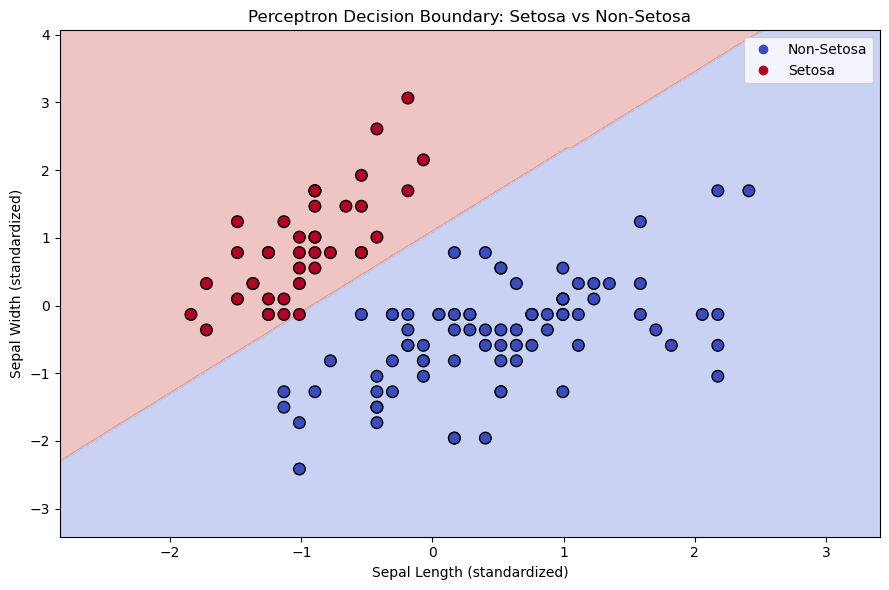

In [6]:
X_2d = X[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = sklearn_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y)

scaler_2d = StandardScaler().fit(X_train_2d)
X_train_2d_scaled = scaler_2d.transform(X_train_2d)

model_2d = Perceptron(learning_rate=0.1, max_iter=100).fit(
    X_train_2d_scaled, y_train_2d)

x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1],
                      c=y_train_2d, cmap='coolwarm', edgecolors='k', s=70)
plt.xlabel('Sepal Length (standardized)')
plt.ylabel('Sepal Width (standardized)')
plt.title('Perceptron Decision Boundary: Setosa vs Non-Setosa')
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Non-Setosa', 'Setosa'])
plt.tight_layout()
plt.show()

## Comparison: Linearly Separable vs Non-Separable Data

The perceptron only converges on linearly separable data. Now it is important to observe what happens when we try to classify a harder, overlapping dataset.

In [10]:
# Generate a non-linearly separable dataset
X_hard, y_hard = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=2,
    class_sep=0.5, random_state=42)

X_h_train, X_h_test, y_h_train, y_h_test = sklearn_split(
    X_hard, y_hard, test_size=0.2, random_state=42)

scaler_h = StandardScaler().fit(X_h_train)
X_h_train_scaled = scaler_h.transform(X_h_train)
X_h_test_scaled = scaler_h.transform(X_h_test)

model_hard = Perceptron(learning_rate=0.1, max_iter=100).fit(
    X_h_train_scaled, y_h_train)

acc_hard = accuracy_score(y_h_test, model_hard.predict(X_h_test_scaled))
print(f"Accuracy on hard (non-separable) dataset: {acc_hard:.4f}")
print(f"(Compare to setosa accuracy of {acc:.4f})")

Accuracy on hard (non-separable) dataset: 0.6250
(Compare to setosa accuracy of 0.9667)


## Discussion

- The Perceptron achieves **96.67% accuracy** on the setosa vs non-setosa classification task with only 1 misclassification out of 30 test samples
- The decision boundary plot shows a clean linear separation between setosa (red) and non-setosa (blue), demonstrating the perceptron has learned a meaningful linear hyperplane
- On the harder, non-linearly-separable synthetic dataset, accuracy drops to just **62.50%**, which is barely better than random guessing on a binary problem
- This dramatic accuracy drop perfectly illustrates the perceptron's fundamental limitation: it can only learn linear decision boundaries
- **Historical significance:** The Perceptron's inability to solve XOR (a non-linearly-separable problem) led to the first AI winter in the 1960s after Minsky and Papert published their critique. This eventually motivated the development of multi-layer neural networks with non-linear activation functions
- Multi-layer perceptrons (which we implement next) overcome this limitation by stacking multiple linear layers with non-linear activations, allowing them to learn arbitrarily complex decision boundaries
- Despite its limitations, the Perceptron remains historically important as the foundation of modern deep learning